In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
## define path
basedir = "/Users/kyokokurihara/iLab/itolab_backup/backup-latest/Lab/projects/2507blastx"

# output directory
path_out = f"{basedir}/output/250909_4474_samples/final_test/"

# input files
# sample info table
sradata_path = f"{basedir}/data/Infection_Prediction_Stacking_0_sample_list_TN1000.txt"
# metatable
meta_in = f"{basedir}/output/250909_4474_samples/final_test/virus_all.blastn.tsv"

# genomad output
genomad_path = f"{basedir}/data/genomad_extra_analysis/virus_metadata_all_ro4.virus_filtered.txt"
genomad_path_v1_11_2 = f"{basedir}/data/genomad_extra_analysis/To_Kurihara_genomad_260130_v2/genomad_out_2/virus_metadata_all_ro4.virus_filtered.txt"

if not os.path.exists(path_out):
    os.mkdir(path_out)
print("saving files:", path_out)

saving files: /Users/kyokokurihara/iLab/itolab_backup/backup-latest/Lab/projects/2507blastx/output/250909_4474_samples/final_test/


# Read tables

In [3]:
## read tables
# sample info table
sampledf = pd.read_table(sradata_path)
print("sample info table size:", sampledf.shape)

# read metadata table
df = pd.read_table(meta_in, dtype={"Project_Id": "Int64"}, index_col=0).drop("query_seq", axis=1)
print("metadata original size:", df.shape)
# remove non-viral hit in blastn
df_blastn = df.loc[~(df["is_virus_blastn"]==0), :].copy()
print("metadata size after removed blastn other hits:", df_blastn.shape)

# genomad output
genomad_all = pd.read_table(genomad_path)
print("genomad output size:", genomad_all.shape)
# add family
genomad_all["family"] = genomad_all["taxonomy"].apply(lambda x: x.split(";")[-1] if x==x else x)
# filter
mask = (genomad_all["virus_score"] >= 0.80) & (genomad_all["marker_enrichment"] >= 1.5) & (genomad_all["n_hallmarks"] >= 1)
genomad_filterd = genomad_all[mask].copy()
print("genomad output size after filtered;", genomad_filterd.shape)
# merge with metadata
genomad_filterd.columns = genomad_filterd.columns.map(lambda x: x + "_genomad_re")
df_g = df_blastn.merge(genomad_filterd, left_on="qseqid", right_on="seq_name_genomad_re", how="left")
print("metadata size after merged with genomad output:", df_g.shape)
# creates column for genomad viral hit
df_g["genomad_positive"] = df_g["seq_name_genomad_re"].notna().astype(int)
df_g["genomad_negative"] = df_g["seq_name_genomad_re"].isna().astype(int)

# genomad v1.11.2 output
genomad_all_v1_11_2 = pd.read_table(genomad_path_v1_11_2)
print("genomad output size:", genomad_all_v1_11_2.shape)
# add family
genomad_all_v1_11_2["family"] = genomad_all_v1_11_2["taxonomy"].apply(lambda x: x.split(";")[-1] if x==x else x)
# filter
mask_v1_11_2 = (genomad_all_v1_11_2["virus_score"] >= 0.80) & (genomad_all_v1_11_2["marker_enrichment"] >= 1.5) & (genomad_all_v1_11_2["n_hallmarks"] >= 1)
genomad_filterd_v1_11_2 = genomad_all_v1_11_2[mask_v1_11_2].copy()
print("genomad output size after filtered;", genomad_filterd_v1_11_2.shape)
# merge with metadata
genomad_filterd_v1_11_2.columns = genomad_filterd_v1_11_2.columns.map(lambda x: x + "_genomad_re")
df_g_v1_11_2 = df_blastn.merge(genomad_filterd_v1_11_2, left_on="qseqid", right_on="seq_name_genomad_re", how="left")
print("metadata size after merged with genomad output:", df_g_v1_11_2.shape)
# creates column for genomad viral hit
df_g_v1_11_2["genomad_positive"] = df_g_v1_11_2["seq_name_genomad_re"].notna().astype(int)
df_g_v1_11_2["genomad_negative"] = df_g_v1_11_2["seq_name_genomad_re"].isna().astype(int)

sample info table size: (4474, 10)
metadata original size: (14353, 57)
metadata size after removed blastn other hits: (14036, 57)
genomad output size: (4298, 13)
genomad output size after filtered; (4298, 14)
metadata size after merged with genomad output: (14036, 71)
genomad output size: (4339, 13)
genomad output size after filtered; (4339, 14)
metadata size after merged with genomad output: (14036, 71)


# Fig5B: Viral detection rates by BLASTx in each fraction

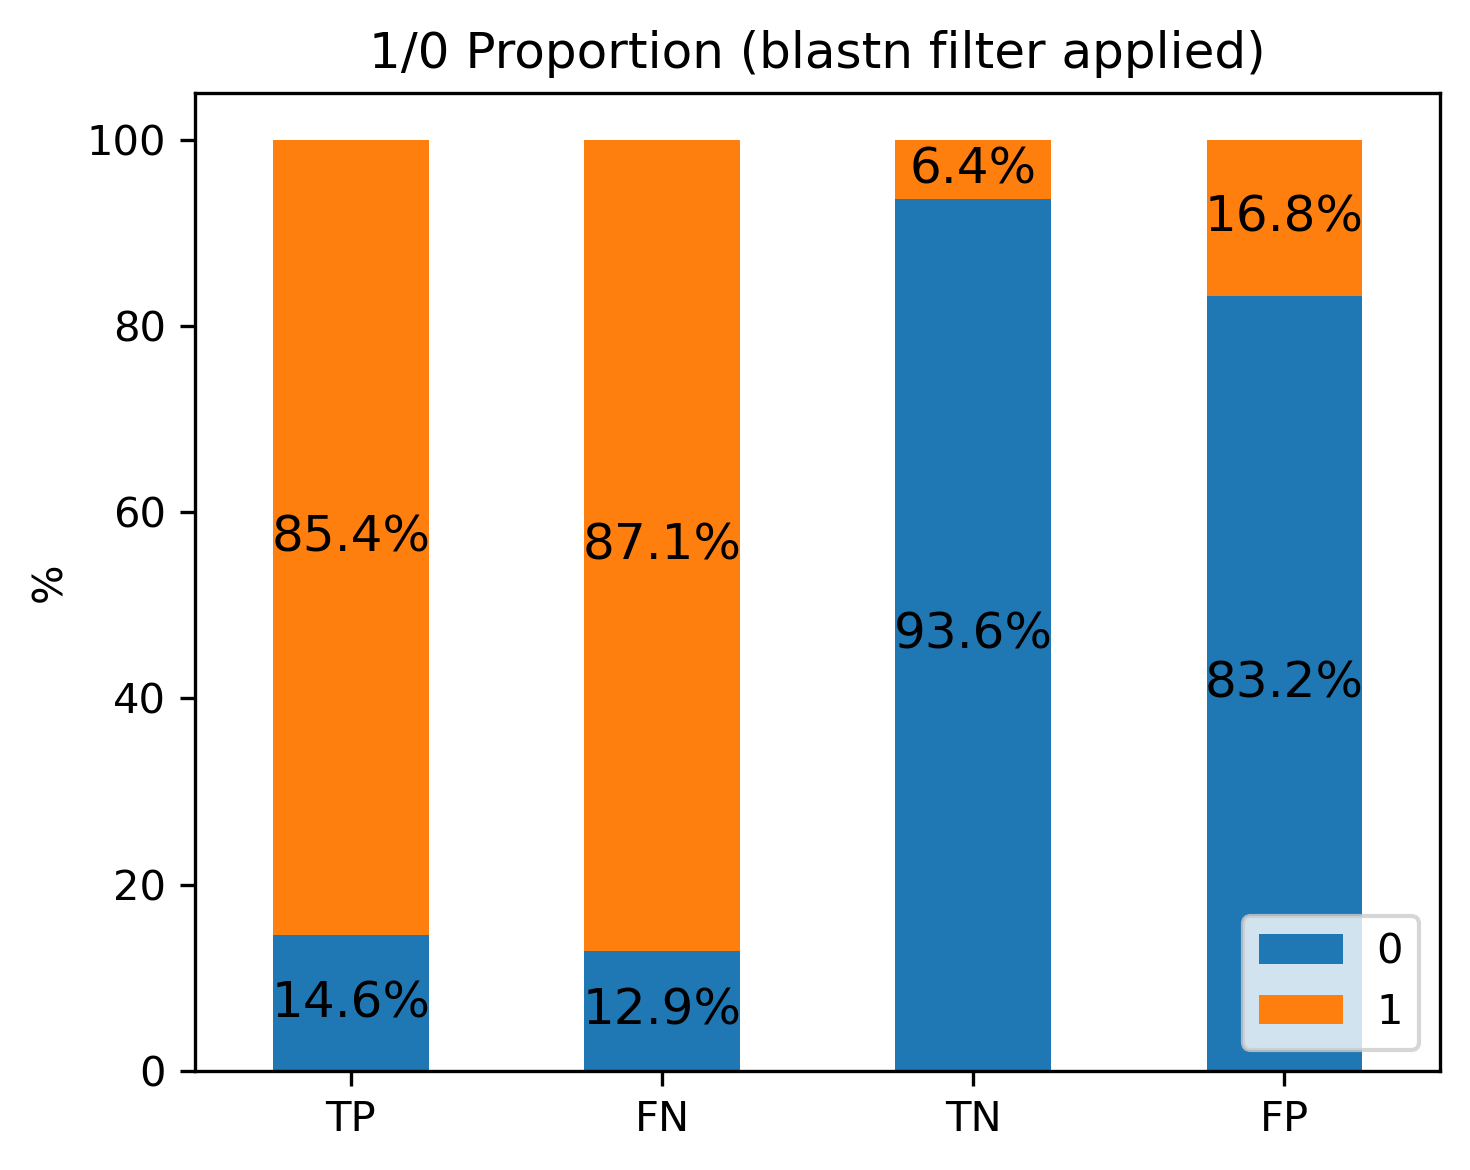

In [4]:
# total count
count_total = pd.DataFrame(sampledf["CM"].value_counts())
count_total.columns = ["total"]

# virus count
count_virus = pd.DataFrame(df_blastn.groupby("sample").first()["cm"].value_counts())

# calc proportion
both_count = count_virus.merge(count_total, left_index=True, right_index=True, how="left")
both_count["0"] = ((both_count["total"] - both_count["count"]) / both_count["total"]) * 100
both_count["1"] = (both_count["count"] / both_count["total"]) * 100
both_count_slim = both_count.loc[["TP", "FN", "TN", "FP"], ["0", "1"]]
# save table
both_count.to_csv(path_out + "virusproportion.blastn.tsv", sep="\t")

# plot
fig, ax = plt.subplots(figsize=(5, 4), dpi=300)
both_count_slim.plot(
    kind="bar",
    stacked=True,
    width=0.5,
    ax=ax,
)
plt.title(f"1/0 Proportion (blastn filter applied)", fontsize=12)
plt.ylabel("%")
plt.xlabel("")
plt.xticks(rotation=0)
plt.legend(fontsize=10, loc="lower right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center", fontsize=12, color="black")

# for illustrater 
mpl.rcParams["pdf.fonttype"] = 42  
mpl.rcParams["ps.fonttype"] = 42  
mpl.rcParams["svg.fonttype"] = "none"  
plt.rcParams["font.family"] = "Arial"

plt.tight_layout()

# save fig
plt.savefig(path_out + "fig5B_virusproportion.blastn.pdf")
plt.show()
plt.close()

# FigS5A:  Reasons why a subset of samples in the TP fraction were not classified as virus-positive by BLASTx-based detection

In [5]:
## samples in TP
# extract TP samples
tp_samples = set(sampledf.loc[sampledf["CM"]=="TP", "ID"].to_list())
# samples with viral hit
df_tp = df.loc[df["cm"] == "TP", :].copy()
tp_samples_hit = set(df_tp["sample"].to_list())
# samples in TP for the final plot
df_blastn_tp = df_blastn.loc[df_blastn["cm"]=="TP"].copy()
tp_samples_hit_blastn = set(df_blastn_tp["sample"].to_list())

print("# all TP samples:", len(tp_samples))
print("# samples with viral hit in BLASTx:", len(tp_samples_hit))
print("# samples with viral hit in BLASTn:", len(tp_samples_hit_blastn))

# all TP samples: 536
# samples with viral hit in BLASTx: 526
# samples with viral hit in BLASTn: 458


# Fig5C: Distribution of BLASTx mean top-hit sequence identity

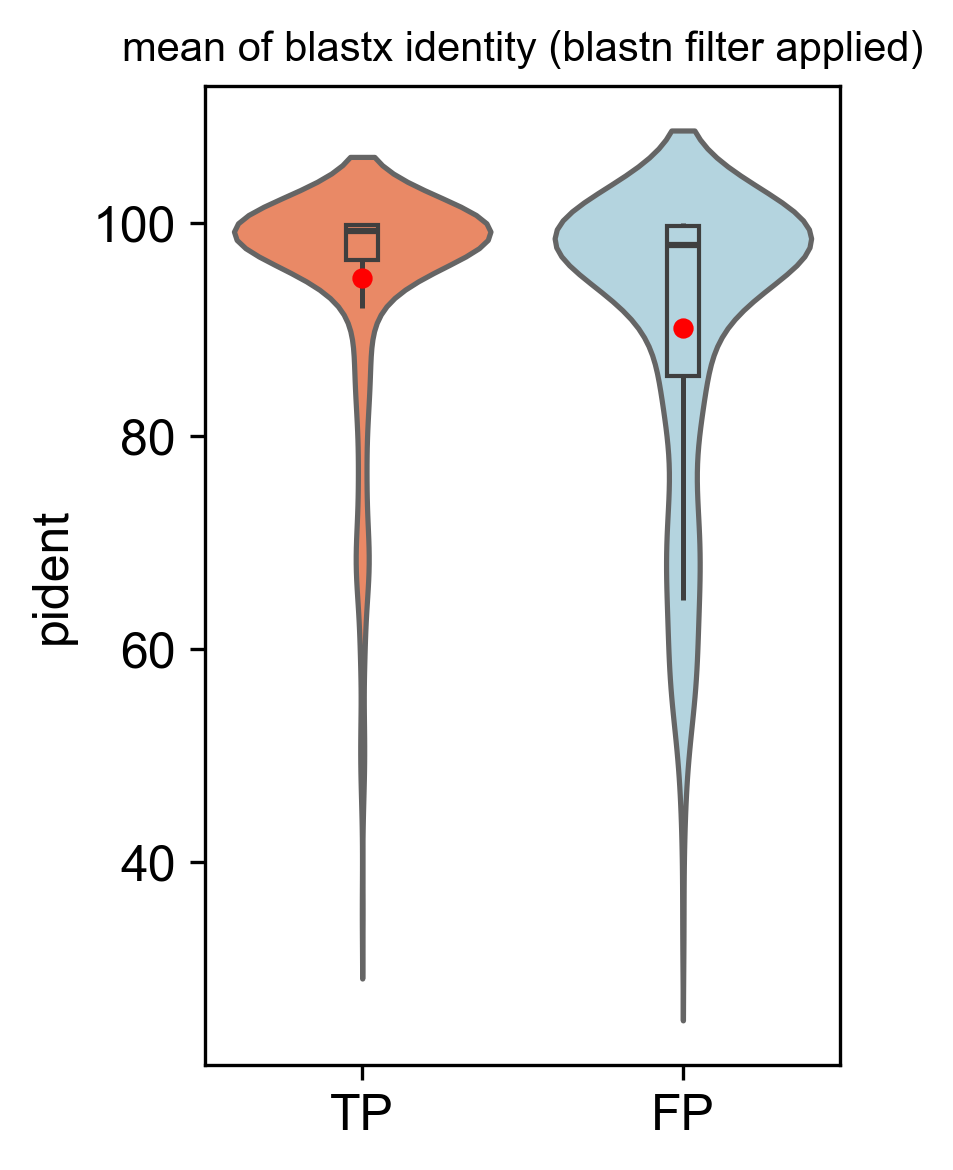

* mean, median
cm             TP          FP
count  458.000000  364.000000
mean    94.855857   90.185307
std     10.631300   14.188836
min     35.300000   33.850000
25%     96.596607   85.635294
50%     99.280357   97.973611
75%     99.880577   99.750000
max    100.000000  100.000000


In [6]:
# calc mean identity per sample per virus (blastn filter applied)
df_ident_blastn_virus_sample = df_blastn[["sample", "genus", "cm", "pident"]].groupby(["sample", "genus"], as_index=False).agg({"cm": "first", "pident": "mean"})[["sample", "cm", "pident"]].groupby("sample").agg({"cm": "first", "pident": "mean"}).copy()

# extract TP and FP
df_ident_tpfp_blastn_virus_sample = df_ident_blastn_virus_sample.loc[((df_ident_blastn_virus_sample["cm"]=="TP")|(df_ident_blastn_virus_sample["cm"]=="FP")), :].copy()

# plot
plt.figure(dpi=300, figsize=(3,4))
cm_order_tpfp = ["TP", "FP"]
color_map_tpfp = {
    "TP": "coral",
    "FP": "lightblue"
}

# violinplot
ax = sns.violinplot(data=df_ident_tpfp_blastn_virus_sample, 
               x="cm", 
               y="pident", 
               hue="cm",
               order=cm_order_tpfp,
               palette=color_map_tpfp,
               fill=True,
               inner=None
              )

# boxplot
sns.boxplot(
    data=df_ident_tpfp_blastn_virus_sample,
    x="cm",
    y="pident",
    order=cm_order_tpfp,
    width=0.1,
    showcaps=False,
    showfliers=False,
    boxprops={"facecolor": "none", "zorder": 3},
    whiskerprops={"linewidth": 1.2},
    medianprops={"linewidth": 1.5},
    ax=ax
)

# mean
means = df_ident_tpfp_blastn_virus_sample.groupby("cm")["pident"].mean().reindex(cm_order_tpfp)
xpos = np.arange(len(cm_order_tpfp))
ax.scatter(
    xpos,
    means.values,
    color="red",
    s=15,
    zorder=5,
)

ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.set_ylabel("pident", fontsize=12)
ax.set_xlabel("")
plt.title("mean of blastx identity (blastn filter applied)", fontsize=10)

# for illustrater 
mpl.rcParams["pdf.fonttype"] = 42  
mpl.rcParams["ps.fonttype"] = 42  
mpl.rcParams["svg.fonttype"] = "none"  
plt.rcParams["font.family"] = "Arial"

plt.tight_layout()

# save fig
plt.savefig(path_out + "fig5C_violinplot_mean_identity_TP_FP.blastn.pdf")
plt.show()
plt.close()

# save table
df_ident_tpfp_blastn_virus_sample.reset_index().pivot(columns='cm', index='sample', values='pident').describe()[["TP", "FP"]].to_csv(path_out + "fig5C_violinplot_mean_identity_TP_FP.blastn.values.txt", sep="\t")
print("* mean, median")
print(df_ident_tpfp_blastn_virus_sample.reset_index().pivot(columns='cm', index='sample', values='pident').describe()[["TP", "FP"]])

In [7]:
# count samples with <=70% identity
thr = 70
ident_summary_cm = (
    df_ident_blastn_virus_sample.groupby("cm")
        .agg(
            total=("pident", "size"),
            under_threshold=("pident", lambda s: (s <= thr).sum()),
          )
          .reset_index()
)
ident_summary_cm["pct_under_threshold"] = (ident_summary_cm["under_threshold"] / ident_summary_cm["total"]) * 100
# save
ident_summary_cm.to_csv(path_out + "fig5C_70%identity_count_per_cm.blastn.tsv", sep="\t")
print(ident_summary_cm)

   cm  total  under_threshold  pct_under_threshold
0  FN    670              153            22.835821
1  FP    364               50            13.736264
2  TN     64               14            21.875000
3  TP    458               31             6.768559


# Fig5D: Cumulative length of BLASTx hit regions per sample

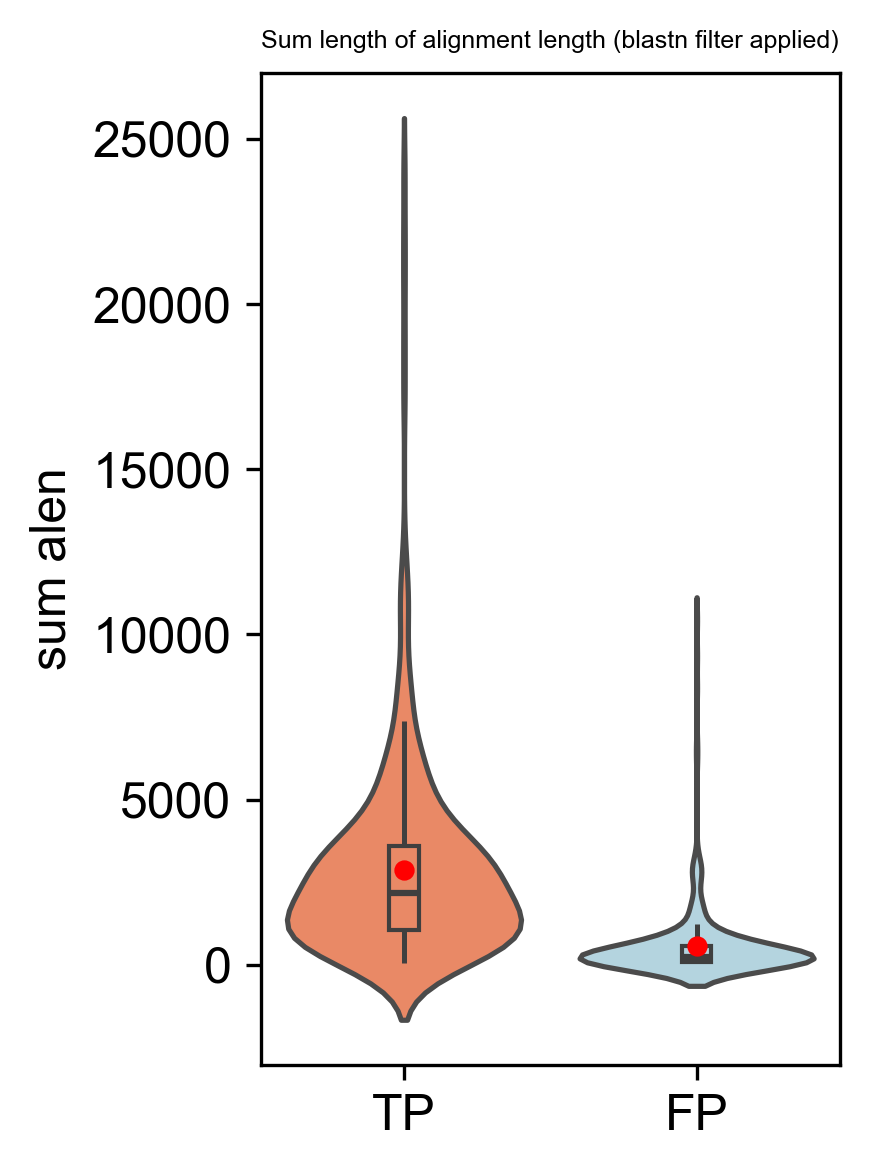

* mean, median
cm               FP            TP
count    364.000000    458.000000
mean     558.711538   2866.593886
std     1100.992929   2914.161656
min       41.000000     49.000000
25%       84.750000   1061.750000
50%      235.500000   2188.000000
75%      577.000000   3605.750000
max    10449.000000  23919.000000

* fold
cm            FP           TP      fold
mean  558.711538  2866.593886  0.194904


In [8]:
# calc sum length of viral contigs per sample (blastn filter applied)
df_sum_alen_blastn = df_blastn[["sample", "cm", "length"]].groupby("sample").agg({"cm": "first", "length": "sum"}).copy()
df_sum_alen_blastn.columns = df_sum_alen_blastn.columns.map(lambda x: x.replace("length", "sum_alen"))

# extract TP and FP
data = df_sum_alen_blastn.loc[df_sum_alen_blastn["cm"].isin(["TP", "FP"]), :].copy()

# plot
plt.figure(dpi=300, figsize=(3,4))
cm_order_tpfp = ["TP", "FP"]
color_map = {
    "TP": "coral",
    "FN": "salmon",
    "FP": "lightblue",
    "TN": "steelblue"
}

# violinplot
ax = sns.violinplot(data=data, 
               x="cm", 
               y="sum_alen", 
               hue="cm",
               order=cm_order_tpfp,
               palette=color_map,
               fill=True,
               inner=None
              )

# boxplot
sns.boxplot(
    data=data,
    x="cm",
    y="sum_alen",
    order=cm_order_tpfp,
    width=0.1,
    showcaps=False,
    showfliers=False,
    boxprops={"facecolor": "none", "zorder": 3},
    whiskerprops={"linewidth": 1.2},
    medianprops={"linewidth": 1.5},
    ax=ax
)

# mean
means = data.groupby("cm")["sum_alen"].mean().reindex(cm_order_tpfp)
xpos = np.arange(len(cm_order_tpfp))
ax.scatter(
    xpos,
    means.values,
    color="red",
    s=15,
    zorder=5,
)

ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.set_ylabel("sum alen", fontsize=12)
ax.set_xlabel("")
plt.title("Sum length of alignment length (blastn filter applied)", fontsize=6)
plt.xlabel("")

# for illustrater
mpl.rcParams["pdf.fonttype"] = 42  
mpl.rcParams["ps.fonttype"] = 42  
mpl.rcParams["svg.fonttype"] = "none"  
plt.rcParams["font.family"] = "Arial"

plt.tight_layout()

# save fig
plt.savefig(path_out + "fig5D_violinplot_sum_alen_TP_FP.blastn.pdf")
plt.show()
plt.close()

# save table
data.reset_index().pivot(columns='cm', index='sample', values='sum_alen').describe().to_csv(path_out + "fig5D_violinplot_sum_alen_TP_FP.blastn.values.txt", sep="\t")
print("* mean, median")
print(data.reset_index().pivot(columns='cm', index='sample', values='sum_alen').describe())

# cacl fold
summary_sum_alen = data.reset_index().pivot(columns='cm', index='sample', values='sum_alen').describe().loc[["mean"], :]
summary_sum_alen["fold"] = summary_sum_alen["FP"]/summary_sum_alen["TP"]
print("\n* fold")
print(summary_sum_alen)

# FigS5B: Proportion of virus-derived contigs identified by BLASTx that were also detected by geNomad

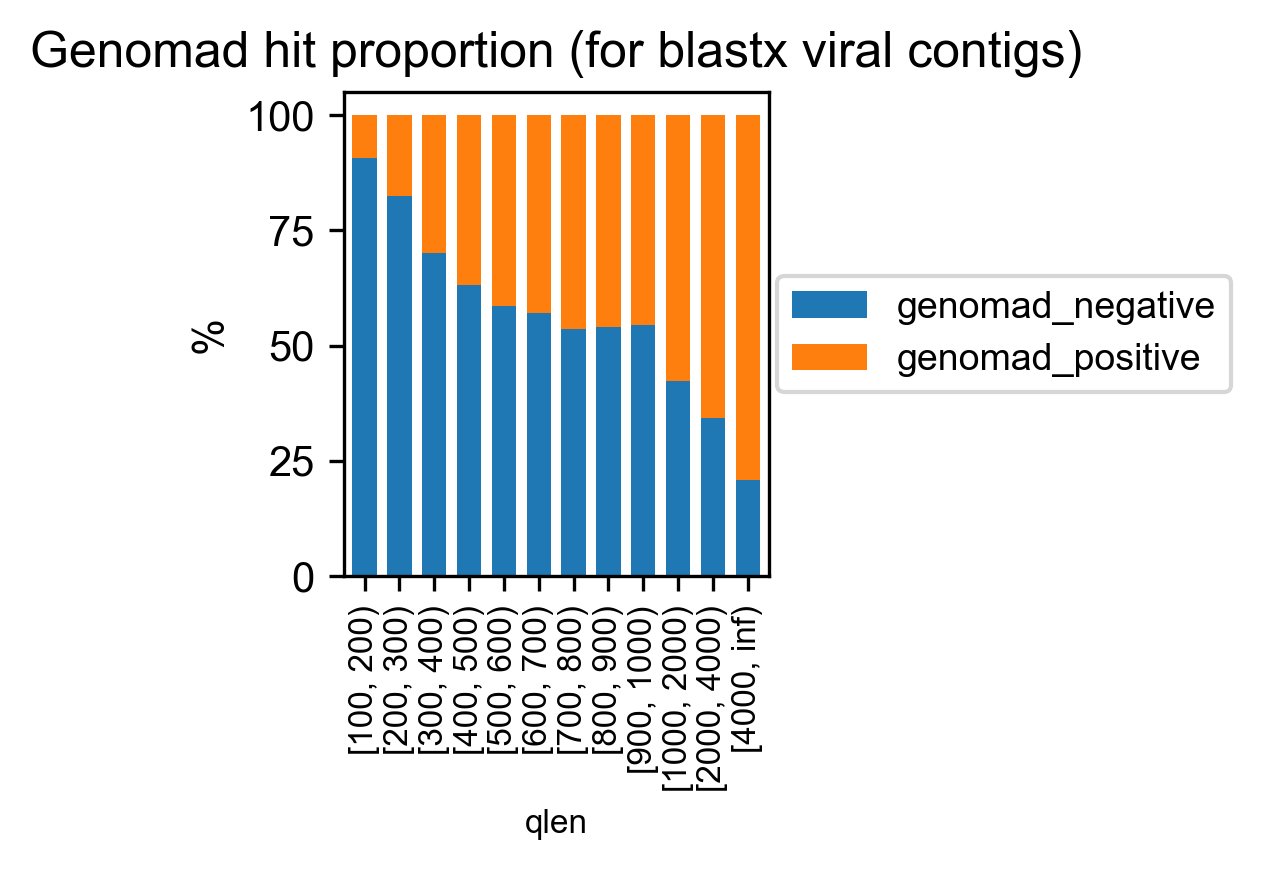

              genomad_positive  genomad_negative   sum
bin                                                   
[100, 200)                 310              3038  3348
[200, 300)                 653              3048  3701
[300, 400)                 493              1155  1648
[400, 500)                 361               620   981
[500, 600)                 283               399   682
[600, 700)                 212               281   493
[700, 800)                 179               206   385
[800, 900)                 123               144   267
[900, 1000)                119               142   261
[1000, 2000)               702               515  1217
[2000, 4000)               400               209   609
[4000, inf)                351                93   444


In [9]:
## binning by qlen
# choose cols
genomad_hit_len= df_g[["sample", "genomad_positive", "genomad_negative", "qlen"]].copy()

# bins
edges1 = np.arange(0, 1000 + 100, 100)  # 100,200,...,1000
edges2 = np.array([1000, 2000, 4000])  # 1000, 2000, 4000
edges = np.r_[edges1, edges2[1:], np.inf]
labels = [f"[{int(a)}, {int(b)})" if np.isfinite(b) else f"[{int(a)}, inf)"
          for a, b in zip(edges[:-1], edges[1:])]
genomad_hit_bin = genomad_hit_len.copy()
genomad_hit_bin["bin"] = pd.cut(genomad_hit_bin["qlen"], bins=edges, labels=labels, right=False, include_lowest=True)

# calc genomad positive rate
genomad_hit_bin_count = genomad_hit_bin[["bin", "genomad_positive", "genomad_negative"]].groupby("bin", observed=True).sum()
genomad_hit_bin_prop = genomad_hit_bin_count.div(genomad_hit_bin_count.sum(axis=1), axis=0)*100

# plot
fig, ax = plt.subplots(figsize=(3.8, 3), dpi=300)
genomad_hit_bin_prop[["genomad_negative", "genomad_positive"]].plot(
    kind="bar",
    stacked=True,
    width=0.7,
    ax=ax,
)

plt.title(f"Genomad hit proportion (for blastx viral contigs)",fontsize=12)
plt.ylabel("%")
plt.xlabel("qlen", fontsize=8)
plt.xticks(rotation=90, fontsize=8)

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0,
    fontsize=9
)

# for illustrater 
mpl.rcParams["pdf.fonttype"] = 42  
mpl.rcParams["ps.fonttype"] = 42  
mpl.rcParams["svg.fonttype"] = "none"  
plt.rcParams["font.family"] = "Arial"

plt.tight_layout()

# save
plt.savefig(path_out + "figS5B_genomad_proportionplot_qlen_bin_slight_for_viral_contigs.pdf")
plt.show()
plt.close()

# show
genomad_hit_bin_count["sum"] = genomad_hit_bin_count.sum(axis=1)
print(genomad_hit_bin_count)

# FigS5E: Proportion of viral infection events detected by geNomad

In [10]:
## infection events (genomad v1.11.2)
# table of infectious event (sample x genus)
df_event = df_g_v1_11_2.copy()
df_event["Parvoviridae_genomad+"] = df_event["family_genomad_re"].apply(lambda x: 1 if x=="Parvoviridae" else 0)
df_event["Parvoviridae_genomad-"] = df_event["family_genomad_re"].apply(lambda x: 1 if x!="Parvoviridae" else 0)
df_event = df_event[["sample", "family", "genus", "pident", "length", "Parvoviridae_genomad+", "Parvoviridae_genomad-"]].groupby(["sample", "genus"]).agg(
    {"family": "first",  "pident": "mean", "length": "sum", "Parvoviridae_genomad+": "sum", "Parvoviridae_genomad-": "sum"})

# extract blastx Parvoviridae
df_event_parvo = df_event[df_event["family"]=="Parvoviridae"].copy()

# check if genomad also detects Parvoviridae
df_event_parvo["Parvoviridae_genomad+_cumulative"] = df_event_parvo["Parvoviridae_genomad+"].apply(lambda x: 1 if x>0 else 0)
df_event_parvo["Parvoviridae_genomad-_cumulative"] = df_event_parvo["Parvoviridae_genomad+"].apply(lambda x: 1 if x==0 else 0)

# count
df_event_parvo_count = df_event_parvo.reset_index()[["genus", "Parvoviridae_genomad+_cumulative", "Parvoviridae_genomad-_cumulative"]].groupby("genus").sum()
df_event_parvo_prop = df_event_parvo_count.div(df_event_parvo_count.sum(axis=1), axis=0)*100

# save
df_event_parvo_count.to_csv(path_out + "genomad_hit_genus_parvo_raw_values_infection_events.tsv", sep="\t")
df_event_parvo_prop.to_csv(path_out + "genomad_prop_genus_parvo_raw_values_infection_events.tsv", sep="\t")

In [11]:
## infection event - cumulative length > 200aa
# table of infectious event (sample x genus)
df_event = df_g_v1_11_2.copy()
df_event["Parvoviridae_genomad+"] = df_event["family_genomad_re"].apply(lambda x: 1 if x=="Parvoviridae" else 0)
df_event["Parvoviridae_genomad-"] = df_event["family_genomad_re"].apply(lambda x: 1 if x!="Parvoviridae" else 0)
df_event = df_event[["sample", "family", "genus", "pident", "length", "Parvoviridae_genomad+", "Parvoviridae_genomad-"]].groupby(["sample", "genus"]).agg(
    {"family": "first",  "pident": "mean", "length": "sum", "Parvoviridae_genomad+": "sum", "Parvoviridae_genomad-": "sum"})

# filter for cumulative length > 200aa
df_event_filtered = df_event.loc[df_event["length"]>200].copy()  ## 
print("before filter:", df_event.shape)
print("after filter:", df_event_filtered.shape)

# extract blastx Parvoviridae
df_event_parvo = df_event_filtered[df_event_filtered["family"]=="Parvoviridae"].copy()

# check if genomad also detects Parvoviridae
df_event_parvo["Parvoviridae_genomad+_cumulative"] = df_event_parvo["Parvoviridae_genomad+"].apply(lambda x: 1 if x>0 else 0)
df_event_parvo["Parvoviridae_genomad-_cumulative"] = df_event_parvo["Parvoviridae_genomad+"].apply(lambda x: 1 if x==0 else 0)

# count
df_event_parvo_count = df_event_parvo.reset_index()[["genus", "Parvoviridae_genomad+_cumulative", "Parvoviridae_genomad-_cumulative"]].groupby("genus").sum()
df_event_parvo_prop = df_event_parvo_count.div(df_event_parvo_count.sum(axis=1), axis=0)*100

# save
df_event_parvo_count.to_csv(path_out + "genomad_hit_genus_parvo_raw_values_infection_events_200aa.tsv", sep="\t")
df_event_parvo_prop.to_csv(path_out + "genomad_prop_genus_parvo_raw_values_infection_events_200aa.tsv", sep="\t")

before filter: (3292, 5)
after filter: (1932, 5)


In [12]:
## infection event - novel virus candidates
# table of infectious event (sample x genus)
df_event = df_g_v1_11_2.copy()
df_event["Parvoviridae_genomad+"] = df_event["family_genomad_re"].apply(lambda x: 1 if x=="Parvoviridae" else 0)
df_event["Parvoviridae_genomad-"] = df_event["family_genomad_re"].apply(lambda x: 1 if x!="Parvoviridae" else 0)
df_event = df_event[["sample", "family", "genus", "pident", "length", "Parvoviridae_genomad+", "Parvoviridae_genomad-"]].groupby(["sample", "genus"]).agg(
    {"family": "first",  "pident": "mean", "length": "sum", "Parvoviridae_genomad+": "sum", "Parvoviridae_genomad-": "sum"})

# filter for candidates for novel virus
df_event_filtered = df_event.loc[(df_event["pident"]<95)&(df_event["length"]>200)].copy()
print("before filter:", df_event.shape)
print("after filter:", df_event_filtered.shape)

# extract blastx Parvoviridae
df_event_parvo = df_event_filtered[df_event_filtered["family"]=="Parvoviridae"].copy()

# check if genomad also detects Parvoviridae
df_event_parvo["Parvoviridae_genomad+_cumulative"] = df_event_parvo["Parvoviridae_genomad+"].apply(lambda x: 1 if x>0 else 0)
df_event_parvo["Parvoviridae_genomad-_cumulative"] = df_event_parvo["Parvoviridae_genomad+"].apply(lambda x: 1 if x==0 else 0)

# count
df_event_parvo_count = df_event_parvo.reset_index()[["genus", "Parvoviridae_genomad+_cumulative", "Parvoviridae_genomad-_cumulative"]].groupby("genus").sum()
df_event_parvo_prop = df_event_parvo_count.div(df_event_parvo_count.sum(axis=1), axis=0)*100

# save
df_event_parvo_count.to_csv(path_out + "genomad_hit_genus_parvo_raw_values_infection_events_novel_candidates.tsv", sep="\t")
df_event_parvo_prop.to_csv(path_out + "genomad_prop_genus_parvo_raw_values_infection_events_novel_candidates.tsv", sep="\t")

before filter: (3292, 5)
after filter: (675, 5)


In [13]:
## creates tables for heatmap
# read tables
# infection events
event_prop = pd.read_table(path_out + "genomad_prop_genus_parvo_raw_values_infection_events.tsv").set_index("genus")[["Parvoviridae_genomad+_cumulative"]]
event_prop.columns = ["infection_events"]
# infection events - cumulative length > 200aa
filtered_event_prop = pd.read_table(path_out + "genomad_prop_genus_parvo_raw_values_infection_events_200aa.tsv").set_index("genus")[["Parvoviridae_genomad+_cumulative"]]
filtered_event_prop.columns = ["infection_events_200aa"]
# infection event - novel virus candidates
novel_event_prop = pd.read_table(path_out + "genomad_prop_genus_parvo_raw_values_infection_events_novel_candidates.tsv").set_index("genus")[["Parvoviridae_genomad+_cumulative"]]
novel_event_prop.columns = ["infection_events_200aa_<95%"]
# merge
both_event_prop = event_prop.merge(novel_event_prop, left_index=True, right_index=True, how="left")
all_event_prop = both_event_prop.merge(filtered_event_prop, left_index=True, right_index=True, how="left")[["infection_events", "infection_events_200aa", "infection_events_200aa_<95%"]]
# save
all_event_prop.to_csv(path_out + "infection_events_three_cols_genomad_positive_rate.tsv", sep="\t")
# show
all_event_prop

,infection_events,infection_events_200aa,infection_events_200aa_<95%
genus,,,
Ambidensovirus,0.000000,NaN,NaN
Amdoparvovirus,33.333333,100.000000,NaN
Aveparvovirus,25.000000,50.000000,0.000000
Bocaparvovirus,36.363636,80.000000,0.000000
Chaphamaparvovirus,0.000000,0.000000,0.000000
Chapparvovirus,0.000000,NaN,NaN
Copiparvovirus,44.444444,70.588235,100.000000
Dependoparvovirus,42.105263,88.888889,100.000000
Erythroparvovirus,57.142857,100.000000,100.000000


In [14]:
# event count
event_count = pd.read_table(path_out + "genomad_hit_genus_parvo_raw_values_infection_events.tsv").set_index("genus")
event_count["total_count"] = event_count.sum(axis=1)
# save
event_count[["total_count"]].to_csv(path_out + "total_count_of_infection_events.tsv", sep="\t")